# Ridge: SNPs vs PCs benchmark

Compare ridge LOIO fit time and predictive accuracy for three feature representations on the same trait:

- **All SNPs** (raw ~180k features)
- **20k random SNPs** (random subset, single seed)
- **1000 PCs** (PCA fit once on the whole filtered dataset, all SNPs)

The second part prepares (but does not run) a nested LOIO CV experiment that searches over the ridge shrinkage `alpha` for the 20k-SNP and PC representations.

Run from the project root so the relative paths resolve.

In [31]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / 'Data').exists() and (path / 'src').exists():
            return path
    raise FileNotFoundError('Could not locate the Master_thesis repo root.')


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.cv_utils import island_label, make_outer_splits
from src.data import load_data
from src.utils import _pearson_corr, set_seed

TRAIT_NAME = 'body_mass'
NPZ_PATH = REPO_ROOT / 'Data' / 'npz' / f'snp_{TRAIT_NAME}_ALL.npz'
TARGET_COLUMN = 'y_adjusted'
EVAL_TARGET_COLUMN = 'y_mean'
MIN_COUNT = 20
# 0-indexed island codes (same convention as final_bpcrr_inla_full_source_1000pc_config.json
# target_islands). After load_data + min_count filtering the 11 northern-system islands map to
# codes 0..10. Set to None to use all available islands.
INCLUDE_ISLANDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
N_PCS = 2000
N_RANDOM_SNPS = 20000
BENCH_ALPHA = 1e5
SEED = 14

set_seed(SEED)
print(f'Repo root: {REPO_ROOT}')
print(f'Trait: {TRAIT_NAME}  (NPZ: {NPZ_PATH.relative_to(REPO_ROOT)})')
print(f'PCs: {N_PCS}   Random SNPs: {N_RANDOM_SNPS}   alpha: {BENCH_ALPHA:g}')

Repo root: c:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
Trait: body_mass  (NPZ: Data\npz\snp_body_mass_ALL.npz)
PCs: 2000   Random SNPs: 20000   alpha: 100000


In [32]:
X_full, y, ids, _, locality, code_to_label, y_eval = load_data(
    paths={'npz': str(NPZ_PATH)},
    target_column=TARGET_COLUMN,
    standardize_features=False,
    return_locality=True,
    min_count=MIN_COUNT,
    return_eval=True,
    eval_target_column=EVAL_TARGET_COLUMN,
)
if y_eval is None:
    y_eval = y.copy()


def _resolve_include_codes(include_islands, locality_codes, code_to_label):
    """Accept either 0-indexed codes or original island labels (e.g. 20, 22, ...)."""
    if not include_islands:
        return None
    present_codes = set(int(c) for c in np.unique(locality_codes))
    label_to_code = {int(v): int(k) for k, v in code_to_label.items()}
    resolved = set()
    for v in include_islands:
        v_int = int(v)
        if v_int in present_codes:
            resolved.add(v_int)
        elif v_int in label_to_code:
            resolved.add(label_to_code[v_int])
        else:
            raise ValueError(
                f'Could not resolve island {v!r}: not a present 0-indexed code and not in '
                f'code_to_label (labels={sorted(label_to_code)}, codes={sorted(present_codes)}).'
            )
    return resolved


include_codes = _resolve_include_codes(INCLUDE_ISLANDS, locality, code_to_label)
if include_codes is not None:
    mask = np.isin(locality, list(include_codes))
    if not mask.any():
        raise ValueError('INCLUDE_ISLANDS filtered out all samples.')
    X_full = X_full[mask]
    y = y[mask]
    ids = ids[mask]
    locality = locality[mask]
    y_eval = y_eval[mask]

n_samples, n_features = int(X_full.shape[0]), int(X_full.shape[1])
n_islands = int(np.unique(locality).size)
kept_islands = sorted(int(c) for c in np.unique(locality))
print(f'Samples: {n_samples}   SNPs: {n_features}   Islands: {n_islands}')
print('Kept islands (code -> original label):')
for c in kept_islands:
    print(f'  {c:>2} -> {code_to_label.get(int(c), "?")} ({island_label(int(c), code_to_label)})')

Samples: 5697   SNPs: 65344   Islands: 15
Kept islands (code -> original label):
   0 -> 20 (Nesøy)
   1 -> 22 (Myken)
   2 -> 23 (Træna)
   3 -> 24 (Selvær)
   4 -> 26 (Gjerøy)
   5 -> 27 (Hestmannøy)
   6 -> 28 (Indre Kvarøy)
   7 -> 33 (Onøy og Lurøy)
   8 -> 34 (Lovund)
   9 -> 35 (Sleneset)
  10 -> 38 (Aldra)
  11 -> 60 (Leka)
  12 -> 61 (Vega)
  13 -> 63 (Vikna)
  14 -> 67 (Lauvøya)


## Pre-compute PCs on the full filtered dataset (all SNPs)

Same as `run_ridge_loio.py` when `use_pcs=True`: PCA is fit once on every sample using every SNP, then the same PC score matrix is reused across all LOIO folds. The fit time below is reported separately and is **not** part of the per-fold ridge timing.

In [23]:
t0 = time.perf_counter()
pca = PCA(n_components=N_PCS, svd_solver='randomized', random_state=SEED)
Z_pcs = pca.fit_transform(X_full).astype(np.float32, copy=False)
pca_fit_time = time.perf_counter() - t0
print(f'PCA fit on full dataset: {pca_fit_time:.2f}s   shape={Z_pcs.shape}   var explained={pca.explained_variance_ratio_.sum():.3f}')

PCA fit on full dataset: 52.48s   shape=(5697, 2000)   var explained=0.782


In [33]:
rng = np.random.default_rng(SEED)
snp_cols_20k = np.sort(rng.choice(n_features, size=N_RANDOM_SNPS, replace=False))
X_20k = X_full[:, snp_cols_20k]
print(f'20k random SNP subset: shape={X_20k.shape}')

20k random SNP subset: shape=(5697, 20000)


## LOIO ridge fit-time comparison

For each LOIO fold we fit `Ridge(alpha)` and measure the wall-clock time of `.fit()` + `.predict()` (so SNPs and PCs are scored consistently). Pearson r on the eval target is reported per fold to make sure each representation actually trains.

In [34]:
feature_sets = {
    'all_snps': X_full,
    'random_20k_snps': X_20k,
    'pcs_2000': Z_pcs,
}

# Per-representation alpha. Falls back to BENCH_ALPHA if a key is missing.
BENCH_ALPHAS = {
    'all_snps': 1e5,
    'random_20k_snps': 1e5,
    'pcs_2000': 1e5,
}

rows = []
for name, X_fit in feature_sets.items():
    alpha_used = float(BENCH_ALPHAS.get(name, BENCH_ALPHA))
    for tr_idx, te_idx, test_island_code in make_outer_splits(
        strategy='leave_island_out',
        locality=locality,
        n_splits=int(np.unique(locality).size),
        shuffle=False,
        random_state=SEED,
        n=len(X_fit),
    ):
        if test_island_code is None:
            continue
        model = Ridge(alpha=alpha_used)
        t0 = time.perf_counter()
        model.fit(X_fit[tr_idx], y[tr_idx])
        pred = model.predict(X_fit[te_idx])
        elapsed = time.perf_counter() - t0
        r = float(_pearson_corr(y_eval[te_idx], pred))
        if not np.isfinite(r):
            r = 0.0
        rows.append({
            'feature_set': name,
            'alpha': alpha_used,
            'n_features_fit': int(X_fit.shape[1]),
            'test_island': island_label(int(test_island_code), code_to_label),
            'test_island_code': int(test_island_code),
            'n_train': int(len(tr_idx)),
            'n_test': int(len(te_idx)),
            'fit_predict_seconds': float(elapsed),
            'pearson_r': float(r),
        })

bench_df = pd.DataFrame(rows)
bench_df.head()

,feature_set,alpha,n_features_fit,test_island,test_island_code,n_train,n_test,fit_predict_seconds,pearson_r
0,all_snps,100000.0,65344,Nesøy,0,5578,119,7.126006,0.223077
1,all_snps,100000.0,65344,Myken,1,5605,92,5.750478,0.430755
2,all_snps,100000.0,65344,Træna,2,5405,292,4.644754,0.162085
3,all_snps,100000.0,65344,Selvær,3,5503,194,4.611949,0.196466
4,all_snps,100000.0,65344,Gjerøy,4,5139,558,4.487398,0.107249


In [35]:
summary = (
    bench_df.groupby('feature_set', as_index=False)
    .agg(
        n_features=('n_features_fit', 'first'),
        alpha=('alpha', 'first'),
        n_folds=('feature_set', 'size'),
        fit_predict_total_s=('fit_predict_seconds', 'sum'),
        fit_predict_mean_s=('fit_predict_seconds', 'mean'),
        fit_predict_median_s=('fit_predict_seconds', 'median'),
        pearson_r_mean=('pearson_r', 'mean'),
        pearson_r_std=('pearson_r', 'std'),
    )
    .sort_values('fit_predict_total_s')
)
summary

,feature_set,n_features,alpha,n_folds,fit_predict_total_s,fit_predict_mean_s,fit_predict_median_s,pearson_r_mean,pearson_r_std
1,pcs_2000,2000,100000.0,15,2.085390,0.139026,0.122348,0.180476,0.123691
2,random_20k_snps,20000,100000.0,15,33.337690,2.222513,2.208242,0.166584,0.112412
0,all_snps,65344,100000.0,15,72.472187,4.831479,4.611949,0.186096,0.117467


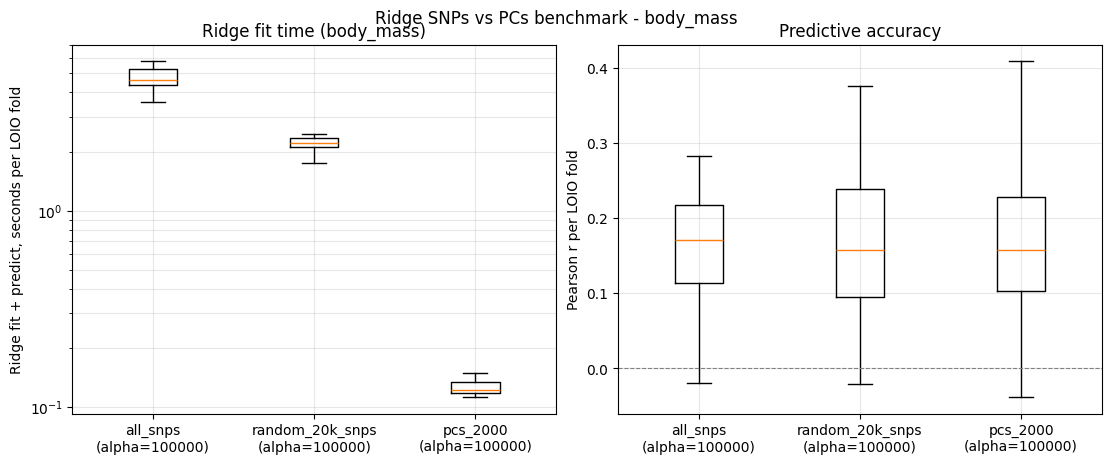

PCA fit time (excluded from per-fold timing above): 52.48s


In [36]:
order = ['all_snps', 'random_20k_snps', 'pcs_2000']
order = [o for o in order if o in set(bench_df['feature_set'])]
labels = [f"{o}\n(alpha={float(BENCH_ALPHAS.get(o, BENCH_ALPHA)):g})" for o in order]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)

ax = axes[0]
data_time = [bench_df.loc[bench_df['feature_set'] == n, 'fit_predict_seconds'].to_numpy() for n in order]
ax.boxplot(data_time, tick_labels=labels, showfliers=False)
ax.set_ylabel('Ridge fit + predict, seconds per LOIO fold')
ax.set_title(f'Ridge fit time ({TRAIT_NAME})')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')

ax = axes[1]
data_r = [bench_df.loc[bench_df['feature_set'] == n, 'pearson_r'].to_numpy() for n in order]
ax.boxplot(data_r, tick_labels=labels, showfliers=False)
ax.set_ylabel('Pearson r per LOIO fold')
ax.set_title('Predictive accuracy')
ax.axhline(0, color='0.5', lw=0.8, ls='--')
ax.grid(True, alpha=0.3)

fig.suptitle(f'Ridge SNPs vs PCs benchmark - {TRAIT_NAME}', y=1.02)
plt.show()
print(f'PCA fit time (excluded from per-fold timing above): {pca_fit_time:.2f}s')

## Prep: nested LOIO CV for optimal ridge shrinkage

Outer loop: LOIO across the included islands. Inner loop: LOIO over the **remaining training islands only** for each outer fold (so the held-out test island never leaks into hyperparameter selection). For each candidate `alpha` we compute the mean inner-fold Pearson r and pick the best, then refit on the full outer training set and score on the held-out island.

The cell below defines the experiment but **does not run it** - `RUN_NESTED_CV = False` short-circuits the loop. Flip the flag (or call `run_nested_alpha_search(...)` directly) to launch.

In [37]:
ALPHA_GRID = [8e4, 1e5, 2e5]
REPRESENTATIONS = {
    'pcs_2000': Z_pcs,
}
RUN_NESTED_CV = True  # set to True to actually run the search

print(f'Alpha grid ({len(ALPHA_GRID)}): {ALPHA_GRID}')
print(f'Representations: {list(REPRESENTATIONS)}')
print(f'Outer folds: {n_islands}   Inner folds per outer: {n_islands - 1}')
print(f'Total ridge fits if executed: {len(REPRESENTATIONS) * n_islands * ((n_islands - 1) * len(ALPHA_GRID) + 1)}')

Alpha grid (3): [80000.0, 100000.0, 200000.0]
Representations: ['pcs_2000']
Outer folds: 15   Inner folds per outer: 14
Total ridge fits if executed: 645


In [38]:
def run_nested_alpha_search(
    X_fit: np.ndarray,
    y_train: np.ndarray,
    y_eval_target: np.ndarray,
    locality_codes: np.ndarray,
    alphas: list,
    seed: int = SEED,
) -> pd.DataFrame:
    """Nested LOIO CV search over ridge alpha.

    Returns one row per outer fold with:
      - test island, n_train/n_test
      - best alpha (highest mean inner Pearson r)
      - mean inner r at the best alpha
      - outer Pearson r when refit at the best alpha
      - full inner_r grid (dict alpha -> mean inner r)
    """
    n_loc = int(np.unique(locality_codes).size)
    rows = []

    for tr_idx, te_idx, test_island_code in make_outer_splits(
        strategy='leave_island_out',
        locality=locality_codes,
        n_splits=n_loc,
        shuffle=False,
        random_state=seed,
        n=len(X_fit),
    ):
        if test_island_code is None:
            continue
        train_loc = locality_codes[tr_idx]
        inner_islands = np.unique(train_loc)

        inner_scores = {float(a): [] for a in alphas}
        for inner_isl in inner_islands:
            inner_te_mask = train_loc == inner_isl
            inner_tr_local = np.where(~inner_te_mask)[0]
            inner_te_local = np.where(inner_te_mask)[0]
            if len(inner_tr_local) < 2 or len(inner_te_local) == 0:
                continue
            inner_tr_idx = tr_idx[inner_tr_local]
            inner_te_idx = tr_idx[inner_te_local]
            for a in alphas:
                m = Ridge(alpha=float(a))
                m.fit(X_fit[inner_tr_idx], y_train[inner_tr_idx])
                pred = m.predict(X_fit[inner_te_idx])
                r = float(_pearson_corr(y_eval_target[inner_te_idx], pred))
                if not np.isfinite(r):
                    r = 0.0
                inner_scores[float(a)].append(r)

        mean_inner = {a: float(np.mean(v)) if v else float('nan') for a, v in inner_scores.items()}
        best_alpha = max(mean_inner, key=lambda a: (mean_inner[a] if np.isfinite(mean_inner[a]) else -np.inf))

        m = Ridge(alpha=float(best_alpha))
        m.fit(X_fit[tr_idx], y_train[tr_idx])
        pred = m.predict(X_fit[te_idx])
        outer_r = float(_pearson_corr(y_eval_target[te_idx], pred))
        if not np.isfinite(outer_r):
            outer_r = 0.0

        rows.append({
            'test_island_code': int(test_island_code),
            'test_island': island_label(int(test_island_code), code_to_label),
            'n_train': int(len(tr_idx)),
            'n_test': int(len(te_idx)),
            'best_alpha': float(best_alpha),
            'mean_inner_r_best': float(mean_inner[best_alpha]),
            'outer_pearson_r': float(outer_r),
            'inner_r_per_alpha': mean_inner,
        })

    return pd.DataFrame(rows)


if RUN_NESTED_CV:
    nested_results = {}
    for name, X_fit in REPRESENTATIONS.items():
        print(f'>>> Running nested LOIO alpha search for {name} (this is slow for all_snps)')
        t0 = time.perf_counter()
        nested_results[name] = run_nested_alpha_search(
            X_fit=X_fit,
            y_train=y,
            y_eval_target=y_eval,
            locality_codes=locality,
            alphas=ALPHA_GRID,
            seed=SEED,
        )
        print(f'    done in {time.perf_counter() - t0:.1f}s')
    for name, df in nested_results.items():
        print(name)
        print(df[['test_island', 'best_alpha', 'mean_inner_r_best', 'outer_pearson_r']])
else:
    print('RUN_NESTED_CV is False - experiment is prepared but not executed.')
    print('Set RUN_NESTED_CV = True in the previous cell to launch.')

>>> Running nested LOIO alpha search for pcs_2000 (this is slow for all_snps)
    done in 78.1s
pcs_2000
      test_island  best_alpha  mean_inner_r_best  outer_pearson_r
0           Nesøy    200000.0           0.172807         0.247480
1           Myken    200000.0           0.160882         0.412215
2           Træna    100000.0           0.182039         0.152796
3          Selvær    100000.0           0.178778         0.176654
4          Gjerøy    200000.0           0.184311         0.105155
5      Hestmannøy    100000.0           0.164679         0.155578
6    Indre Kvarøy    200000.0           0.157396         0.301675
7   Onøy og Lurøy    100000.0           0.203649        -0.038127
8          Lovund    200000.0           0.153805         0.402944
9        Sleneset    200000.0           0.175007         0.185524
10          Aldra    200000.0           0.179986         0.178865
11           Leka    200000.0           0.177819         0.157019
12           Vega    100000.0        

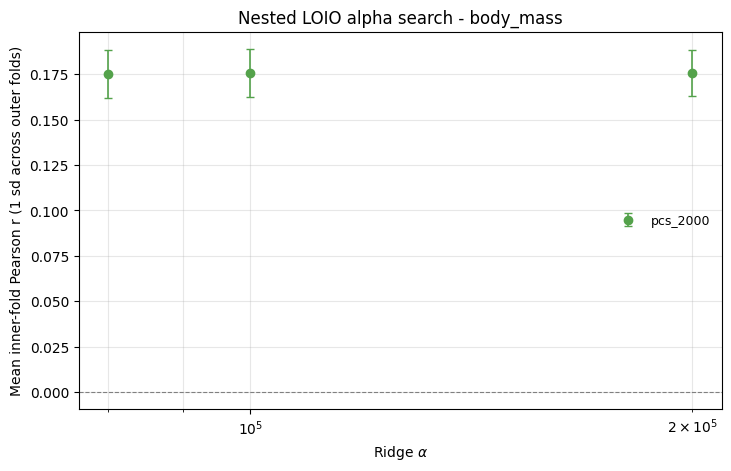

In [39]:
def plot_inner_r_vs_alpha(nested_results, alphas=ALPHA_GRID):
    """For each representation, plot mean inner Pearson r per alpha (across outer folds)
    with 1-sd error bars."""
    fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)
    colors = {'random_20k_snps': '#F58518', 'pcs_2000': '#54A24B'}
    fallback = plt.get_cmap('tab10')

    items = list(nested_results.items())
    n_series = len(items)
    log_step = (np.log10(alphas[1]) - np.log10(alphas[0])) if len(alphas) > 1 else 0.0
    offsets = np.linspace(-0.08, 0.08, n_series) * log_step if n_series > 1 else np.zeros(n_series)

    for i, (name, df) in enumerate(items):
        if df.empty:
            continue
        grid = pd.DataFrame(list(df['inner_r_per_alpha']))
        grid = grid.reindex(columns=[float(a) for a in alphas])
        means = grid.mean(axis=0).to_numpy()
        sds = grid.std(axis=0, ddof=1).to_numpy()
        xs = np.asarray([float(a) for a in alphas], dtype=float) * (10.0 ** offsets[i])
        color = colors.get(name, fallback(i % 10))
        ax.errorbar(
            xs, means, yerr=sds,
            fmt='o', color=color, ecolor=color, capsize=3, lw=1.2, markersize=6,
            label=name,
        )

    ax.set_xscale('log')
    ax.set_xlabel(r'Ridge $\alpha$')
    ax.set_ylabel('Mean inner-fold Pearson r (1 sd across outer folds)')
    ax.set_title(f'Nested LOIO alpha search - {TRAIT_NAME}')
    ax.axhline(0, color='0.5', lw=0.8, ls='--')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(frameon=False, fontsize=9)
    return fig


if 'nested_results' in globals() and nested_results:
    plot_inner_r_vs_alpha(nested_results, alphas=ALPHA_GRID)
    plt.show()
else:
    print('No nested_results in scope yet - run the previous cell with RUN_NESTED_CV=True first.')